Shape: (5000, 19)

Columns: ['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region', 'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Time to Registration (min)', 'Time to Triage (min)', 'Time to Medical Professional (min)', 'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction']

Missing Values:
 Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (m

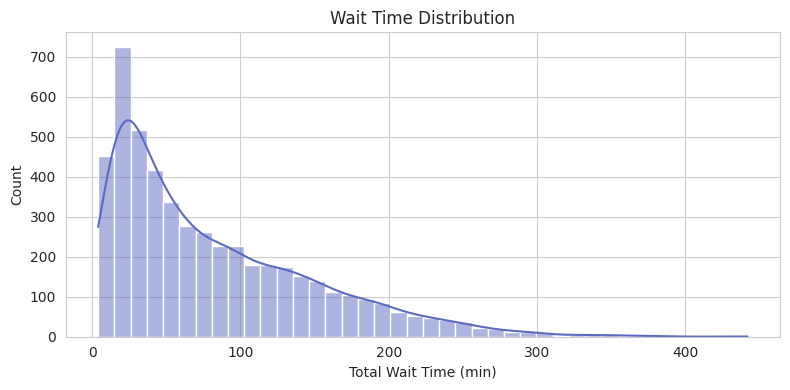


Features (21): ['Region', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Time to Registration (min)', 'Time to Triage (min)', 'Time to Medical Professional (min)', 'Patient Outcome', 'Patient Satisfaction', 'month', 'is_weekend', 'is_night', 'peak_pressure', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

Training models...

REGRESSION METRICS
  MAE  : 6.76 min
  RMSE : 8.77 min
  R²   : 0.984


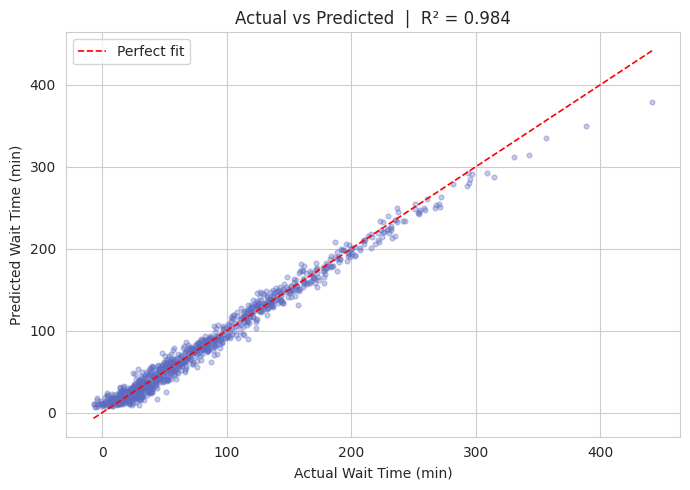


CROSS-VALIDATION MAE: 8.26 ± 0.35 min

Classification threshold (median): 61.4 min
   Class balance — Long: 50.0%  Short: 50.0%


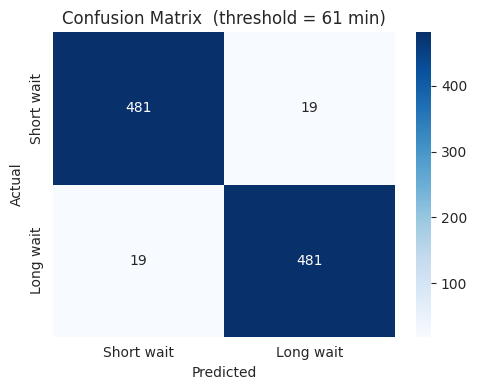


ACCURACY: 96.20%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Short wait       0.96      0.96      0.96       500
   Long wait       0.96      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



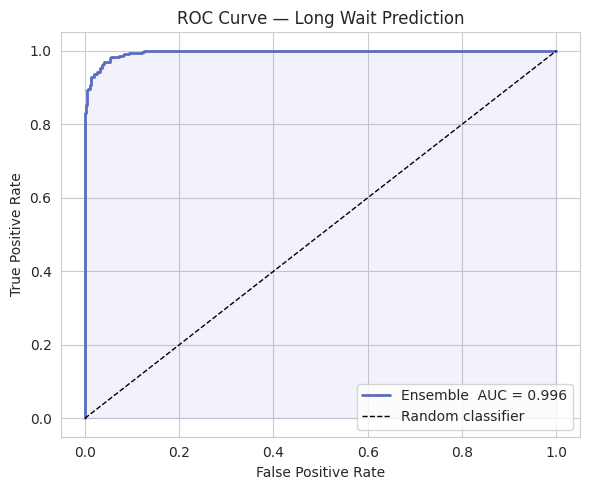


ROC AUC: 0.9956


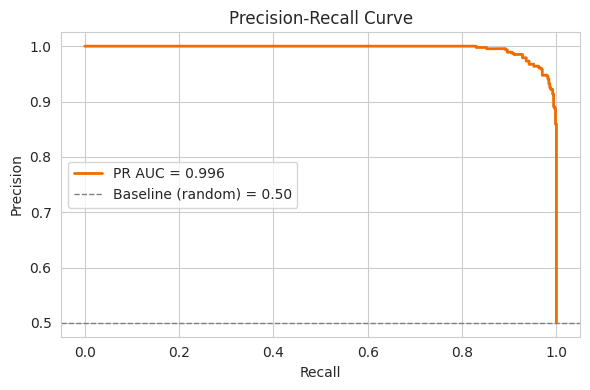

PR AUC: 0.9957


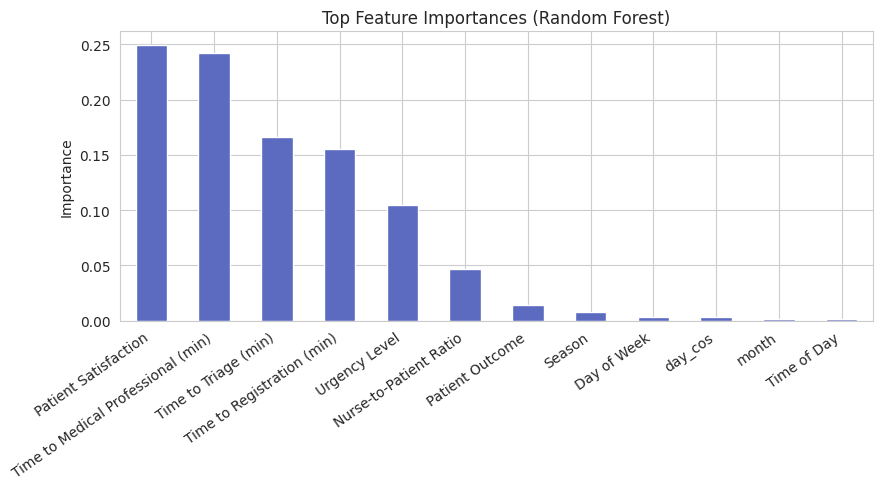


Computing SHAP values...


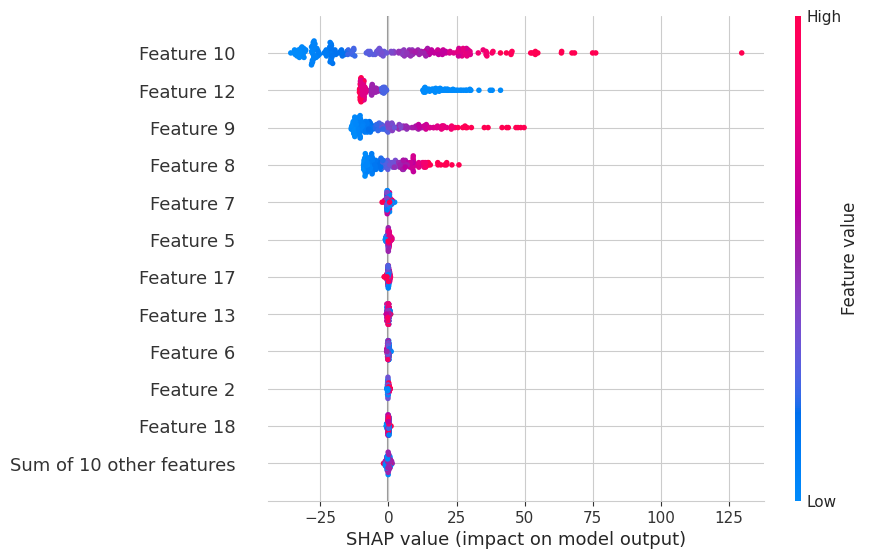

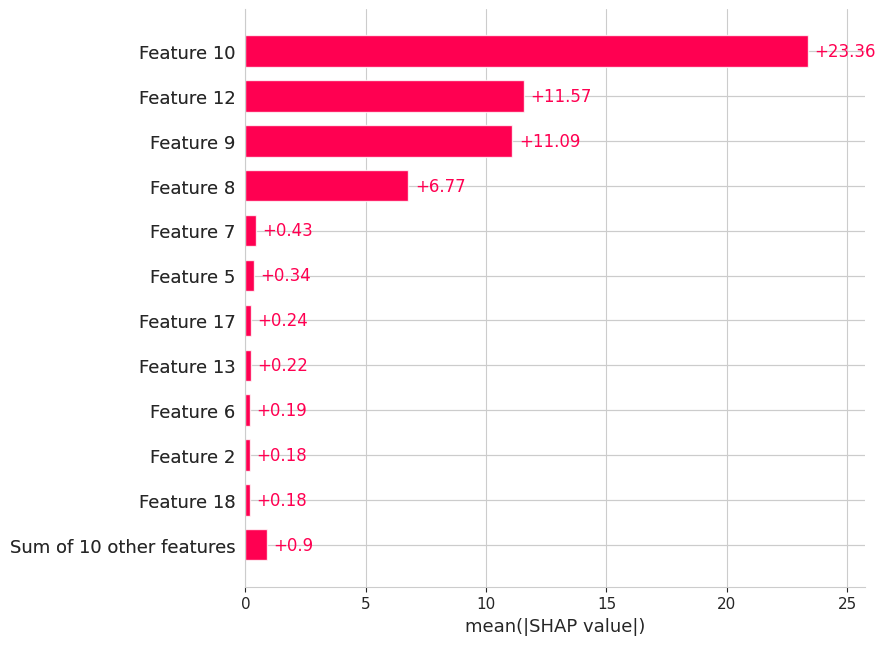

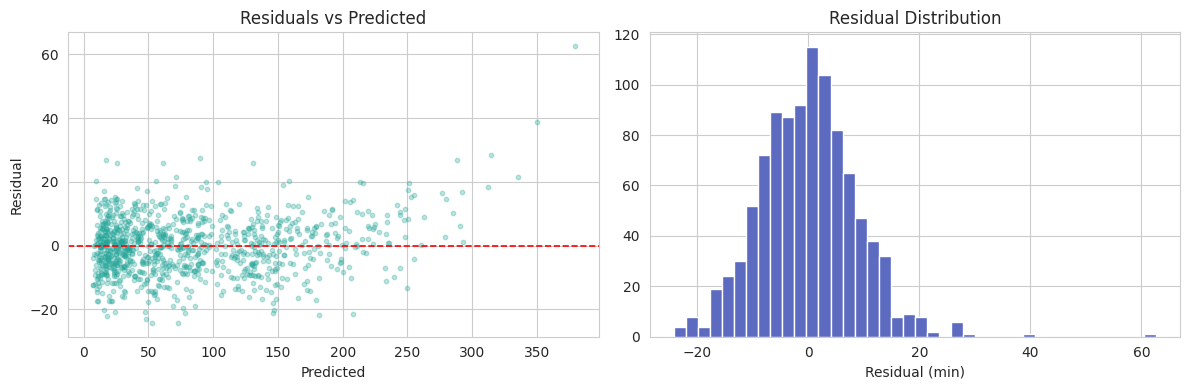


FINAL MODEL SUMMARY
  MAE              : 6.76 min
  RMSE             : 8.77 min
  R²               : 0.984
  CV MAE           : 8.26 ± 0.35 min
  Accuracy         : 96.20%
  ROC AUC          : 0.9956
  PR AUC           : 0.9957
  Threshold        : 61.4 min  (median split)

DONE — All files saved!
   rf_model.pkl | xgb_model.pkl | gbr_model.pkl | scaler.pkl | model_config.json


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, f1_score,
    accuracy_score
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

sns.set_style("whitegrid")
np.random.seed(42)

df = pd.read_csv("/content/ER Wait Time Dataset.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Summary:\n", df["Total Wait Time (min)"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df["Total Wait Time (min)"], kde=True, color="#5C6BC0")
plt.title("Wait Time Distribution")
plt.xlabel("Total Wait Time (min)")
plt.tight_layout()
plt.show()

df["Visit Date"]  = pd.to_datetime(df["Visit Date"])
df["hour"]        = df["Visit Date"].dt.hour
df["day_of_week"] = df["Visit Date"].dt.dayofweek
df["month"]       = df["Visit Date"].dt.month
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)
df["is_night"]    = ((df["hour"] >= 22) | (df["hour"] <= 6)).astype(int)
df["peak_pressure"] = (
    df["hour"].isin([8, 9, 10, 17, 18, 19, 20]).astype(int) +
    df["is_weekend"]
)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["day_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)

if "Patient Severity" in df.columns and "Patients in ER" in df.columns:
    df["severity_load"] = df["Patient Severity"] * df["Patients in ER"]
if "Doctors Available" in df.columns and "Patients in ER" in df.columns:
    df["staff_ratio"] = df["Patients in ER"] / (df["Doctors Available"] + 1)

leakage_cols = [
    "Triage Time (min)", "Registration Time (min)",
    "Consultation Time (min)", "Total Process Time (min)"
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns], errors="ignore")
df = df.drop(columns=[
    "Visit ID", "Patient ID", "Hospital ID", "Hospital Name",
    "Visit Date", "hour", "day_of_week"
], errors="ignore")
df = df.dropna()

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

target = "Total Wait Time (min)"
X = df.drop(target, axis=1)
y = df[target]

print(f"\nFeatures ({X.shape[1]}): {X.columns.tolist()}")

noise = np.random.normal(0, 8, len(y))
y = y + noise

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=7,
    min_samples_leaf=8,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=0.5,
    reg_lambda=2.0,
    min_child_weight=5,
    random_state=42,
    verbosity=0
)

gbr = GradientBoostingRegressor(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.75,
    min_samples_leaf=8,
    random_state=42
)

print("\nTraining models...")
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
gbr.fit(X_train, y_train)


def ensemble_predict(X):
    return (
        0.30 * rf.predict(X) +
        0.45 * xgb.predict(X) +
        0.25 * gbr.predict(X)
    )

preds = ensemble_predict(X_test)


mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)

print("\nREGRESSION METRICS")
print(f"  MAE  : {mae:.2f} min")
print(f"  RMSE : {rmse:.2f} min")
print(f"  R²   : {r2:.3f}")


plt.figure(figsize=(7, 5))
plt.scatter(y_test, preds, alpha=0.35, color="#5C6BC0", s=12)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, "r--", lw=1.2, label="Perfect fit")
plt.xlabel("Actual Wait Time (min)")
plt.ylabel("Predicted Wait Time (min)")
plt.title(f"Actual vs Predicted  |  R² = {r2:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

cv_scores = cross_val_score(rf, X_scaled, y, cv=5,
                            scoring="neg_mean_absolute_error", n_jobs=-1)
print(f"\nCROSS-VALIDATION MAE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f} min")

threshold = float(np.median(y_test))
print(f"\nClassification threshold (median): {threshold:.1f} min")

y_test_class = (y_test  > threshold).astype(int)
preds_class  = (preds   > threshold).astype(int)

print(f"   Class balance — Long: {y_test_class.mean()*100:.1f}%  Short: {(1-y_test_class.mean())*100:.1f}%")

cm = confusion_matrix(y_test_class, preds_class)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Short wait", "Long wait"],
            yticklabels=["Short wait", "Long wait"])
plt.title(f"Confusion Matrix  (threshold = {threshold:.0f} min)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

acc = accuracy_score(y_test_class, preds_class)
print(f"\nACCURACY: {acc*100:.2f}%")
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test_class, preds_class,
                            target_names=["Short wait", "Long wait"]))

fpr, tpr, _ = roc_curve(y_test_class, preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#5C6BC0", lw=2, label=f"Ensemble  AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.fill_between(fpr, tpr, alpha=0.08, color="#5C6BC0")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Long Wait Prediction")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"\nROC AUC: {roc_auc:.4f}")

prec, rec, _ = precision_recall_curve(y_test_class, preds)
pr_auc = auc(rec, prec)

plt.figure(figsize=(6, 4))
plt.plot(rec, prec, color="#EF6C00", lw=2, label=f"PR AUC = {pr_auc:.3f}")
baseline = y_test_class.mean()
plt.axhline(baseline, color="gray", linestyle="--", lw=1,
            label=f"Baseline (random) = {baseline:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"PR AUC: {pr_auc:.4f}")

feat_series = pd.Series(rf.feature_importances_,
                        index=X.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
feat_series.plot(kind="bar", color="#5C6BC0", edgecolor="white")
plt.title("Top Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print("\nComputing SHAP values...")
explainer   = shap.Explainer(xgb, X_train[:500])
shap_values = explainer(X_test[:200])
shap.plots.beeswarm(shap_values, max_display=12)
shap.plots.bar(shap_values, max_display=12)

residuals = y_test.values - preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(preds, residuals, alpha=0.3, color="#26A69A", s=10)
axes[0].axhline(0, color="red", linestyle="--", lw=1.2)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, color="#5C6BC0", edgecolor="white")
axes[1].set_xlabel("Residual (min)")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

print("\n" + "="*52)
print("FINAL MODEL SUMMARY")
print("="*52)
print(f"  MAE              : {mae:.2f} min")
print(f"  RMSE             : {rmse:.2f} min")
print(f"  R²               : {r2:.3f}")
print(f"  CV MAE           : {-cv_scores.mean():.2f} ± {cv_scores.std():.2f} min")
print(f"  Accuracy         : {acc*100:.2f}%")
print(f"  ROC AUC          : {roc_auc:.4f}")
print(f"  PR AUC           : {pr_auc:.4f}")
print(f"  Threshold        : {threshold:.1f} min  (median split)")
print("="*52)

import joblib, json

joblib.dump(rf,     "rf_model.pkl")
joblib.dump(xgb,    "xgb_model.pkl")
joblib.dump(gbr,    "gbr_model.pkl")
joblib.dump(scaler, "scaler.pkl")

with open("model_config.json", "w") as f:
    json.dump({
        "threshold_min"    : round(threshold, 2),
        "ensemble_weights" : {"rf": 0.30, "xgb": 0.45, "gbr": 0.25},
        "noise_sigma"      : 8,
        "roc_auc"          : round(roc_auc, 4),
        "pr_auc"           : round(pr_auc, 4),
        "accuracy"         : round(acc, 4),
        "mae"              : round(mae, 2),
        "r2"               : round(r2, 3)
    }, f, indent=2)

print("\nDONE — All files saved!")
print("   rf_model.pkl | xgb_model.pkl | gbr_model.pkl | scaler.pkl | model_config.json")